In [11]:
import pandas as pd
import numpy as np

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from tabulate import tabulate
from SQUIC_functions import *
from collections import defaultdict

In [12]:
accounts_csv = f"accounts.csv"
transactions_csv = f"transactions.csv"

In [13]:
account_prop = {}
max_steps = 200

accounts_df = pd.read_csv(accounts_csv)

# Setup account mapping and initial state
unique_accounts = sorted(accounts_df['ACCOUNT_ID'])

initial_balances = {}
fraud_accounts = set()

for _, row in accounts_df.iterrows():
    acc_id = row['ACCOUNT_ID']
    initial_balances[acc_id] = float(row['INIT_BALANCE'])
    if str(row['IS_FRAUD']) == 'true':
        fraud_accounts.add(acc_id)

# Initialize structures
df = pd.DataFrame(index=range(max_steps), columns=unique_accounts, dtype=float)
for acc_id in unique_accounts:
    df.loc[:, acc_id] = initial_balances[acc_id]

current_balances = initial_balances.copy()
edge_weights = defaultdict(float)
    
# Process transactions by timestamp chunks to maintain balance accuracy
chunk_size = 100000

# Read and process transactions chunk by chunk, sorting each chunk
for chunk in pd.read_csv(transactions_csv, chunksize=chunk_size):
    chunk['IS_FRAUD'] = chunk['IS_FRAUD'].astype(str).str == 'true'
    chunk = chunk.sort_values('TIMESTAMP')
            
    for _, row in chunk.iterrows():
        timestamp = int(row['TIMESTAMP'])
            
        sender_id = row['SENDER_ACCOUNT_ID']
        receiver_id = row['RECEIVER_ACCOUNT_ID']
        amount = float(row['TX_AMOUNT'])
        is_fraud = row['IS_FRAUD']
        
        # Update balances and DataFrame directly
        if sender_id in current_balances:
            current_balances[sender_id] -= amount
            df.loc[timestamp:, sender_id] = current_balances[sender_id]
            
        if receiver_id in current_balances:
            current_balances[receiver_id] += amount
            df.loc[timestamp:, receiver_id] = current_balances[receiver_id]
        
        # Update transaction matrix
        edge_weights[(sender_id, receiver_id)] += amount
        
        # Track fraud
        if is_fraud:
            fraud_accounts.add(sender_id)
            fraud_accounts.add(receiver_id)
    
    del chunk

# Create transaction matrix and account properties (same as before)
max_account_id = len(unique_accounts)

if edge_weights:
    rows, cols, data = zip(*[(i, j, amt) for (i, j), amt in edge_weights.items()])
    transaction_matrix = coo_matrix((data, (rows, cols)), 
                                    shape=(max_account_id, max_account_id)).tolil()
else:
    transaction_matrix = lil_matrix((max_account_id, max_account_id), dtype=float)

account_prop = {}
for i, acc_id in enumerate(unique_accounts):
    account_prop[i] = {
        "fraud": acc_id in fraud_accounts,
    }

In [14]:
df

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,184.44,175.80,142.06,0.01,151.13,140.49,178.38,240.20,147.66,158.34,...,1970.87,2003.49,2021.47,1035.51,228.15,505.04,232.48,433.74,733.72,414.21
1,184.44,175.80,142.06,-125.87,151.13,140.49,178.38,240.20,147.66,158.34,...,3906.09,4247.91,3456.31,2473.23,629.74,863.83,277.24,697.62,1380.83,520.12
2,184.44,175.80,142.06,-251.75,151.13,140.49,178.38,240.20,147.66,158.34,...,6453.45,7247.03,5578.29,4370.97,261.70,883.60,304.16,1307.15,1805.36,866.03
3,184.44,175.80,142.06,-251.75,151.13,140.49,178.38,240.20,147.66,158.34,...,9015.04,10664.13,6756.00,5978.22,974.83,921.38,131.35,1516.45,2628.90,1610.57
4,184.44,175.80,142.06,-251.75,151.13,140.49,178.38,240.20,147.66,158.34,...,11674.79,14435.14,9031.86,7597.62,1856.49,1098.21,618.02,1903.67,3546.84,698.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-2967.92,5052727.53,-2556.89,3005625.82,-2720.15,-2669.11,305465.58,2459.42,-425.25,-3324.70,...,11097918.04,12089534.68,14601036.72,34797516.99,9492793.06,10375104.27,13883185.18,21491333.73,14277318.48,19663746.89
196,-2967.92,5052727.53,-2556.89,3005625.82,-2720.15,-2669.11,305465.58,2329.10,-425.25,-3324.70,...,11100682.32,12092694.17,14603000.41,34798617.05,9493690.94,10375317.70,13883494.04,21491715.32,18981127.13,28210785.13
197,-2967.92,5052727.53,-2698.94,3005625.82,-2871.27,-2669.11,305465.58,2473.21,-425.25,-3324.70,...,11103791.12,12096145.37,25520923.82,34800442.38,9494511.40,10375612.51,15319097.36,21492112.69,25189362.25,32950725.75
198,-2967.92,5052727.53,-2840.99,3005625.82,-2871.27,-2669.11,305465.58,2473.21,-425.25,-3324.70,...,11106926.33,12099808.82,25522420.66,34802337.63,9495067.33,10375776.06,15319154.74,21492140.61,25187826.64,32951384.43


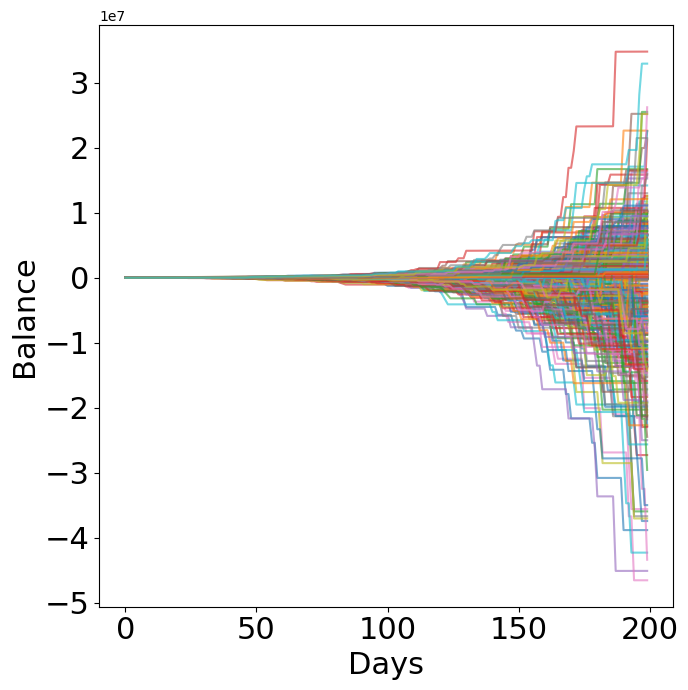

In [15]:
plt.figure(figsize=(7,7))

# Plot each column (account balance) as a line
for user in df.columns:
    plt.plot(df.index, df[user], label=f"User {user}", alpha=0.6)

# Add title and labels
plt.xlabel("Days", fontsize=22)
plt.ylabel("Balance", fontsize=22)

# Rotate x-axis labels for better visibility
plt.tick_params(axis='x', labelsize=22)
plt.tick_params(axis='y', labelsize=22)

# Display the plot
plt.tight_layout()
plt.show()

In [16]:
Y = df.T.values

In [17]:
Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation

In [18]:
print("NaNs?", np.isnan(Y_new).any())
print("Infs?", np.isinf(Y_new).any())
print("Max:", np.max(Y_new))
print("Min:", np.min(Y_new))
print("Mean std per row (should be 1):", round(np.mean(np.std(Y_new, axis=1)), 2))

NaNs? False
Infs? False
Max: 14.186670781892827
Min: -7.777750057078516
Mean std per row (should be 1): 1.0


In [19]:
# Compute std dev per row
row_std = np.std(Y, axis=1, keepdims=True)

# Avoid division by zero
row_std[row_std == 0] = 1.0

# Normalize each row
Y_new = Y / row_std

In [20]:
print("NaNs?", np.isnan(Y_new).any())
print("Infs?", np.isinf(Y_new).any())
print("Max:", np.max(Y_new))
print("Min:", np.min(Y_new))
print("Mean std per row (should be 1):", round(np.mean(np.std(Y_new, axis=1)), 2))

NaNs? False
Infs? False
Max: 14.186670781892827
Min: -7.777750057078516
Mean std per row (should be 1): 1.0


In [11]:
# l = [0.9999, 0.999, 0.998, 0.997, 0.995, 0.99]
l = [0.99999999, 0.9999999, 0.999999, 0.999995, 0.99999, 0.9999, 0.999]

In [12]:
Theta_dict = {}

In [13]:
ROWS = Y_new.shape[0]
ROWS

10000

In [14]:
from sklearn.neighbors import NearestNeighbors
import networkx as nx

In [15]:
G_trans = nx.from_scipy_sparse_array(transaction_matrix)
print(f"Graph given by transaction matrix is connected? {nx.is_connected(G_trans)}")

Graph given by transaction matrix is connected? False


In [16]:
n_neighbors = 10
nbrs = NearestNeighbors(n_neighbors=n_neighbors + 1, metric='euclidean', n_jobs=-1)
nbrs.fit(Y_new)
knn_matrix = nbrs.kneighbors_graph(Y_new, mode='connectivity')

G_knn = nx.from_scipy_sparse_array(knn_matrix)

print(f"Graph given by KNN on timeseries is connected? {nx.is_connected(G_knn)}")

Graph given by KNN on timeseries is connected? True


# SQUIC

In [17]:
# data_nnz = []
# data_nnzr = []
# data_time = []
# data_sym = []

# for rho in l:
#     Theta, _, computation_time = compute_squic(Y_new, rho)
#     computation_time = round(computation_time, 2)
#     print(f"time required: {computation_time} seconds")

#     Theta = sparse.csr_matrix(Theta) # store Theta as sparse
#     Theta_dict[rho] = Theta

#     nonz, nonz_r = nnz_sparse(Theta_dict[rho], ROWS)

#     print("Checking if symmetric")
#     if check_symmetric_sparse(Theta_dict[rho]):
#         print(f"✅ Matrix is symmetric per rho {rho}")
#         data_sym.append('Yes')
#     else:
#         print(f"❌ Matrix is not symmetric per rho {rho}")
#         data_sym.append('No')

#     data_nnz.append(nonz)
#     data_nnzr.append(nonz_r)
#     data_time.append(computation_time)

#     if nonz == ROWS:
#         print(f"For rho = {rho} just element on the diagonal")
#         sparsity_pattern(Theta_dict[rho])
#     elif nonz == ROWS * ROWS:
#         print(f"For rho = {rho} big dense matrix")
#         print(f"nnz = {nonz}")
#         print(f"nnz/row = {nonz_r}")
#         sparsity_pattern(Theta_dict[rho])
#     else:
#         print(f"For rho = {rho} there are some nnz")
#         print(f"nnz = {nonz}")
#         print(f"nnz/row = {nonz_r}")
#         sparsity_pattern(Theta_dict[rho])


# table_squic_norm = [
#     ["NNZ"] + data_nnz,
#     ["NNZ/Row"] + data_nnzr,
#     ["Time (s)"] + data_time,
#     ["Symmetric"] + data_sym
# ]

# SQUIC-Fit


----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    1.551720e+01
 Y:         10000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e+00 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=9.97e+00 time=7.68e-02
* iter=1 time=1.04e-01 obj=1.82e+04 |delta(obj)|/obj=4.50e-01 nnz(X,L,W)/p=[9.97e+00 8.81e+01 1.00e+00] lns_iter=5 
* iter=2 time=1.43e-01 obj=1.75e+04 |delta(obj)|/obj=4.05e-02 nnz(X,L,W)/p=[9.97e+00 8.81e+01 3.09e+01] lns_iter=6 
* iter=3 time=9.08e-01 obj=1.62e+04 |

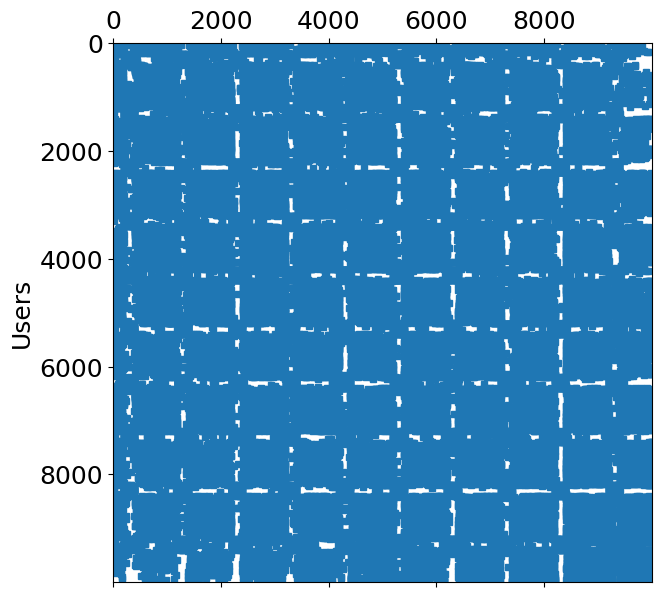

 Matrix is symmetric per rho 0.99999999
For rho 0.99999999 not connected graph
Number of connected components: 53

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    1.551720e+01
 Y:         10000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.999999e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=9.97e+00 time=7.41e-02
* iter=1 time=1.13e-01 obj=1.82e+04 |delta(obj)|/obj=4.50e-01 nnz(X,L,W)/p=[9.97e+00 8.81e+01 1.00e+00] lns_iter=5 
* iter=2 time=1.46e-01 obj=1.75e+04 |de

In [ ]:
W_dict = {}

data_nnz = []
data_nnzr = []
data_time = []
data_sym = []

for rho in l:
    W_dict[rho], end_time = squic_fit_matrix_sparse(Y=Y_new, l=rho, bias_matrix=knn_matrix)
    end_time = round(end_time, 2)
    print(f"required time: {end_time}")

    # Get diagonal elements
    diagonal = W_dict[rho].diagonal()

    # Check if all diagonal element are zero
    if not np.all(diagonal == 0):
        print("There are some non zero(s) on the diagonal.")

    nnz, nnz_r = nnz_sparse(W_dict[rho], ROWS)
    print(f"nnz = {nnz} per rows = {nnz_r}")

    print_matrix(W_dict[rho])

    if check_symmetric_sparse(W_dict[rho]):
        print(f" Matrix is symmetric per rho {rho}")
    else:
        print(f" Matrix is not symmetric per rho {rho}")
    
    G = nx.from_scipy_sparse_array(W_dict[rho])
    if not nx.is_connected(G):
        print(f"For rho {rho} not connected graph")
        components = list(nx.connected_components(G))
        print(f"Number of connected components: {len(components)}")
        # for i, comp in enumerate(components):
        #     print(f"Component {i+1}: {comp}")
    else:
        print("Graph is fully connected")
    
    data_nnz.append(nnz)
    data_nnzr.append(nnz_r)
    data_time.append(end_time)

table_fit_norm = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time,
    ["Symmetric"] + data_sym
]

In [37]:
X = W_dict[0.5]
X.todense()
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1990 stored elements and shape (100, 100)>
  Coords	Values
  (0, 1)	0.007848326366324616
  (0, 3)	0.0345479654918677
  (0, 14)	0.008658218832974057
  (0, 16)	0.014297337981241416
  (0, 20)	0.020735968561329497
  (0, 24)	0.02399925152756369
  (0, 26)	0.04473814326224648
  (0, 29)	0.03867739565540417
  (0, 30)	0.0020483615413827427
  (0, 31)	0.03297931502888417
  (0, 32)	0.018494937345459435
  (0, 33)	0.018719777852041274
  (0, 34)	0.04823905293631149
  (0, 36)	0.04072796825043935
  (0, 40)	0.02730572458193542
  (0, 41)	0.02578748657909719
  (0, 44)	4.6861667011735596e-05
  (0, 45)	0.0066144004013025046
  (0, 46)	0.004508193115011397
  (0, 49)	0.029133468592649744
  (0, 50)	0.01520380873527842
  (0, 51)	0.01807488582257214
  (0, 52)	0.0009079134807614096
  (0, 54)	0.032385683862086435
  (0, 59)	0.028340143610327412
  :	:
  (98, 84)	0.020241955897462548
  (98, 85)	0.033194879214736905
  (98, 87)	2.570596628333415e-05
  (98, 91)

In [16]:
from tabulate import tabulate

In [17]:
def table(data, title, l):
    table = tabulate(
        data,
        headers=[title] + l,
        tablefmt="fancy_grid",
        numalign="center",
        stralign="center"
    )
    return table

In [18]:
print(table(table_squic_norm, "SQUIC NORM", l))

print(table(table_fit_norm, "SQUIC FIT NORM", l))

╒══════════════╤═══════╤═══════╤═══════╤═══════╤════════╕
│  SQUIC NORM  │  0.9  │  0.5  │  0.2  │  0.1  │  0.09  │
╞══════════════╪═══════╪═══════╪═══════╪═══════╪════════╡
│     NNZ      │ 2774  │ 4372  │ 3574  │ 3088  │  3120  │
├──────────────┼───────┼───────┼───────┼───────┼────────┤
│   NNZ/Row    │ 27.74 │ 43.72 │ 35.74 │ 30.88 │  31.2  │
├──────────────┼───────┼───────┼───────┼───────┼────────┤
│   Time (s)   │ 0.06  │ 0.31  │ 0.24  │ 1.12  │  1.03  │
├──────────────┼───────┼───────┼───────┼───────┼────────┤
│  Symmetric   │  Yes  │  Yes  │  Yes  │  Yes  │  Yes   │
╘══════════════╧═══════╧═══════╧═══════╧═══════╧════════╛
╒══════════════════╤═══════╤═══════╤═══════╤═══════╤════════╕
│  SQUIC FIT NORM  │  0.9  │  0.5  │  0.2  │  0.1  │  0.09  │
╞══════════════════╪═══════╪═══════╪═══════╪═══════╪════════╡
│       NNZ        │ 1590  │ 2090  │ 1502  │ 4114  │  1542  │
├──────────────────┼───────┼───────┼───────┼───────┼────────┤
│     NNZ/Row      │ 15.9  │ 20.9  │ 15.02 │ 41.14 │

In [19]:
def labels_to_partition(labels):
    """Convert label array [0,0,1,1,2,2] -> list of sets [{0,1},{2,3},{4,5}]"""
    clusters = {}
    for idx, label in enumerate(labels):
        if label not in clusters:
            clusters[label] = set()
        clusters[label].add(idx)

    # Remove noise points if using DBSCAN (-1 labels)
    if -1 in clusters:
        noise_nodes = clusters.pop(-1)
        for node in noise_nodes:
            clusters[f'noise_{node}'] = {node}  # unique labels for noise

    return list(clusters.values())

In [44]:
import networkx as nx
from networkx.algorithms import community
from sklearn.cluster import DBSCAN, SpectralClustering
from sklearn.manifold import SpectralEmbedding
from tqdm.auto import tqdm  # Correct import for progress bars

def clustering(W_matrices):
    dict_cluster = {
        "louvain" : {},
        "spectral" : {},
        "dbscan" : {}
    }

    for rho, W in W_matrices.items():
        # Ensure all off-diagonal entries are positive and diagonal is zero
        W.data = np.abs(W.data)
        W.setdiag(0)
        W.eliminate_zeros()  # Remove explicit zeros

        # Create a graph from matrix W
        G = nx.from_scipy_sparse_array(W)

        embedding = SpectralEmbedding(n_components=10, affinity='precomputed')
        X = embedding.fit_transform(W)      

        # Louvain
        partition = community.louvain_communities(G)
        print(f"n cluster louvain : {len(partition)}")
        dict_cluster['louvain'][rho] = partition

        n_cluster_louvain =  len(partition)


        # DBSCAN with multiple params
        best_score = float('inf')
        best_params = None

        eps_range = np.linspace(0.1, 2.0, 20)
        min_samples_range = range(3, 10)

        for eps in tqdm(eps_range):
            for min_samples in min_samples_range:
                dbscan = DBSCAN(eps=eps, min_samples=min_samples)
                labels = dbscan.fit_predict(X)
                
                # Ignore if all points are noise (-1) or single cluster
                if len(set(labels)) <= 1 or (set(labels) == {-1}):
                    continue

                partition = labels_to_partition(labels)

                diff = abs(len(partition) - n_cluster_louvain)
                if diff < best_score:
                    best_score = diff
                    best_params = (eps, min_samples)

        if best_params is not None:
            print(f"Best params: eps={best_params[0]}, min_samples={best_params[1]}")
            print(f"Best difference in number of clusters: {best_score:.4f}")
            dbscan = DBSCAN(eps=best_params[0], min_samples=best_params[1])
        else:
            print("No suitable DBSCAN parameters found!")
            dbscan = DBSCAN()

        labels_dbscan = dbscan.fit_predict(X)
        print(f"n cluster dbscan = {len(labels_dbscan)}")

        # Convert labels to list of sets
        partition_dbscan = labels_to_partition(labels_dbscan)
        dict_cluster['dbscan'][rho] = partition_dbscan


        # Use n_cluster = len(partitionin louvain)
        clustering = SpectralClustering(n_clusters=n_cluster_louvain, affinity='precomputed', assign_labels='cluster_qr')
        labels_spectral = clustering.fit_predict(X)

        # Convert labels to list of sets
        partition_spectral = labels_to_partition(labels_spectral)
        print(f"n cluster spectral = {len(labels_spectral)}\n")

        dict_cluster['spectral'][rho] = partition_spectral
    
    return dict_cluster

In [45]:
dict_cluster = clustering(W_dict)

# Connected components: 28
Largest component size: 73
n cluster louvain : 29


/opt/anaconda3/envs/bank/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


  0%|          | 0/20 [00:00<?, ?it/s]

Best params: eps=0.7, min_samples=7
Best difference in number of clusters: 1.0000
n cluster dbscan = 100
n cluster spectral = 100

# Connected components: 2
Largest component size: 99
n cluster louvain : 6


/opt/anaconda3/envs/bank/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


...

Best params: eps=0.4, min_samples=3
Best difference in number of clusters: 1.0000
n cluster dbscan = 100
n cluster spectral = 100

# Connected components: 1
Largest component size: 100
n cluster louvain : 5


  0%|          | 0/20 [00:00<?, ?it/s]

Best params: eps=0.5, min_samples=8
Best difference in number of clusters: 0.0000
n cluster dbscan = 100
n cluster spectral = 100

# Connected components: 1
Largest component size: 100
n cluster louvain : 5


  0%|          | 0/20 [00:00<?, ?it/s]

Best params: eps=0.2, min_samples=3
Best difference in number of clusters: 2.0000
n cluster dbscan = 100
n cluster spectral = 100

